In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl

In [48]:
rois = ['M1', 'M2', 'M3', 'M4',
        'A1', 'A2', 'A3', 
        'D1', 'D2', 'D3', 'D4', 
        'S1', 'S2', 'S3', 'S4', 'S5']

In [49]:
df_GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_Nettekoven_2024_GM_mod_slope.tsv'), sep = '\t')
df_GM['hemisphere'] = df_GM.regionname.str[2]

In [50]:
for roi in rois:
    patient_df_l = df_GM[(df_GM.regionname == roi + 'L') & (df_GM.isPatient==1)]
    patient_df_r = df_GM[(df_GM.regionname == roi + 'R') & (df_GM.isPatient==1)]
    
    patients_r = np.array(patient_df_r['mean'])
    patients_l = np.array(patient_df_l['mean'])

    t_val, p_val = stats.ttest_rel(patients_l, patients_r)

    print(f'**t-test for GM in {roi}L vs {roi}R** \n t-value: {t_val} \t p-value: {p_val}')


**t-test for GM in M1L vs M1R** 
 t-value: -1.5113329369131143 	 p-value: 0.13968074768126434
**t-test for GM in M2L vs M2R** 
 t-value: -3.4547994820854173 	 p-value: 0.0014603750828704248
**t-test for GM in M3L vs M3R** 
 t-value: -1.9999628169657224 	 p-value: 0.053311851966621124
**t-test for GM in M4L vs M4R** 
 t-value: -2.3442936080738805 	 p-value: 0.024866326224648582
**t-test for GM in A1L vs A1R** 
 t-value: -0.13077519458477496 	 p-value: 0.8967019390024245
**t-test for GM in A2L vs A2R** 
 t-value: -1.5446544655836116 	 p-value: 0.1314246805951808
**t-test for GM in A3L vs A3R** 
 t-value: -1.641349725121768 	 p-value: 0.10968194810121144
**t-test for GM in D1L vs D1R** 
 t-value: -3.401519892445204 	 p-value: 0.001690790815340091
**t-test for GM in D2L vs D2R** 
 t-value: -2.3864339984866296 	 p-value: 0.022552199923566194
**t-test for GM in D3L vs D3R** 
 t-value: -0.011741308804447908 	 p-value: 0.9906986791295753
**t-test for GM in D4L vs D4R** 
 t-value: -1.7756449583

In [ ]:
ipsi_palette = sns.color_palette('Purples', n_colors=len(rois))
contra_palette = sns.light_palette('pink', n_colors=len(rois))
controls_palette = sns.color_palette('Greens', n_colors=len(rois))

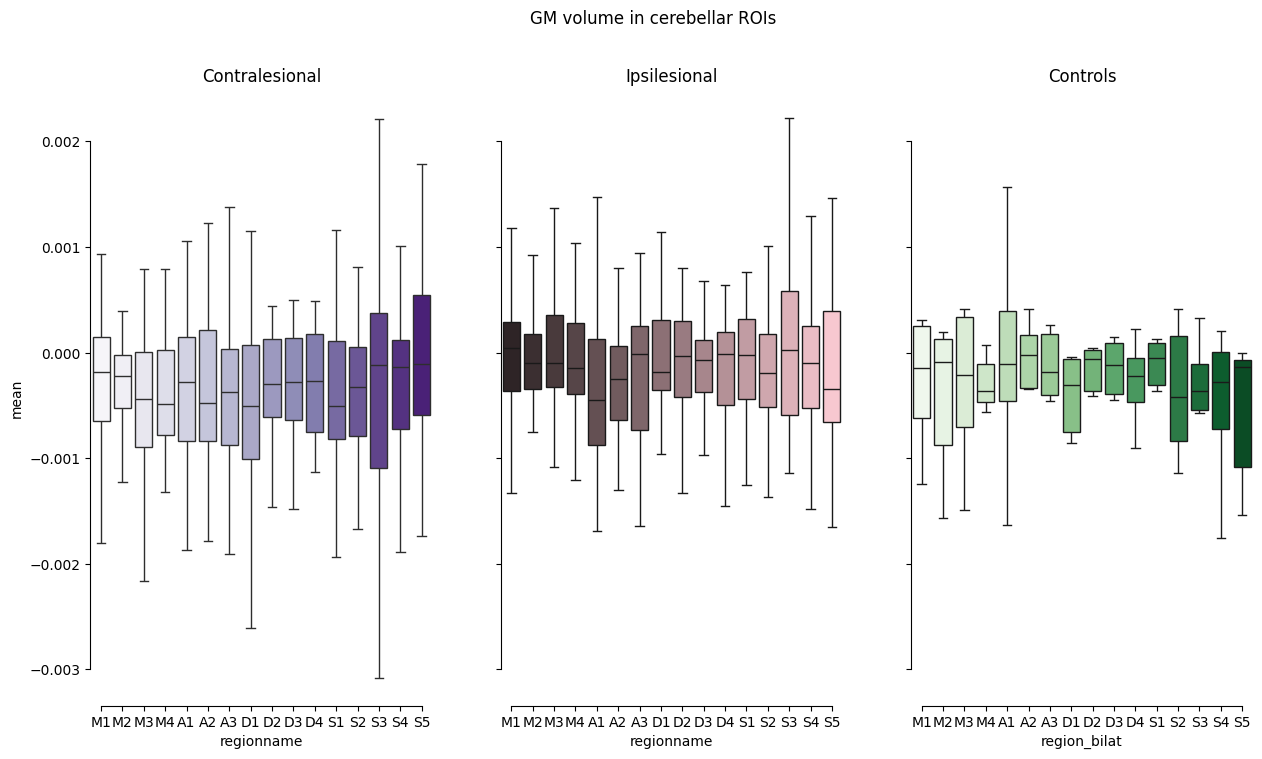

In [52]:
patients_df = df_GM[df_GM.isPatient == 1]
plot_l = patients_df[patients_df.regionname.str[2]=='L'] # contralesional
plot_r = patients_df[patients_df.regionname.str[2]=='R'] # ipsilesional

controls_df = df_GM[df_GM.isPatient == 0].copy()
controls_df['region_bilat'] = controls_df.regionname.str[:2]
controls_bilat = controls_df.groupby(['subj_id', 'region_bilat']).agg({'mean': 'mean'}).reset_index()

fig, axs = plt.subplots(1,3, figsize = (15,8), sharey = True)
sns.boxplot(data = plot_l, x = 'regionname', y = 'mean', hue = 'regionname', showfliers = False, ax = axs[0], palette = ipsi_palette)
sns.boxplot(data = plot_r, x = 'regionname', y = 'mean', hue = 'regionname', showfliers = False, ax = axs[1], palette = contra_palette)
sns.boxplot(data = controls_bilat, x = 'region_bilat', y = 'mean', hue = 'region_bilat', showfliers = False, ax = axs[2], palette = controls_palette)

axs[0].set_title("Contralesional")
axs[1].set_title("Ipsilesional")
axs[2].set_title("Controls")


#plt.legend(bbox_to_anchor = (1, .7))
for ax in axs:
    ax.set_xticks(ticks = np.arange(len(rois)), labels = rois)

plt.suptitle("GM volume in cerebellar ROIs")
sns.despine(trim = True)
plt.show()